# Playing Cards Classification — EfficientNet-B2

## Project Description
This project implements an image classification system for playing cards using **EfficientNet-B2** with transfer learning and two-stage fine-tuning. It was developed as part of a Master's degree lab assignment.

The goal was to **outperform three baseline models** provided by the professor:
| Model | Test Accuracy (professor's baseline) |
|---|---|
| MobileNetV2 | 90.19% |
| Vision Transformer B16 | 90.94% |
| Custom CNN | 75.09% |

## ✅ Result
**EfficientNet-B2 achieved 96.23% test accuracy**, surpassing all three baselines.

## Dataset
[Cards Image Dataset — Kaggle](https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification)
- 224×224×3 images in JPG format
- 53 classes (standard playing cards + joker)
- 8,154 images: 7,624 train / 265 validation / 265 test

## ⚠️ Note on reproducibility
This notebook was developed in **Google Colab Pro** due to GPU memory requirements (~11 GB). It is not intended to run locally. All outputs and results are preserved in the cells below.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q '/content/drive/MyDrive/02 - CNN-Cards/Datasets/Cards.zip' -d '/content/sample_data/Datasets'

replace /content/sample_data/Datasets/Cards/test/ace of clubs/1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!pip install --upgrade keras-hub --quiet
!pip install --upgrade keras --quiet

In [ ]:
import tensorflow as tf
import keras_hub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [ ]:
print(tf.__version__)

print(tf.test.gpu_device_name())

if tf.test.is_built_with_gpu_support():
    print('Se detectó una GPU')
else:
    print('No se detectó una GPU')

2.19.0
/device:GPU:0
Se detectó una GPU


In [ ]:
!nvidia-smi

Fri Dec 12 14:21:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P0             31W /   70W |     102MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import time
import copy
import random
import numpy as np
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader

In [ ]:
DATA_PATH = '/content/sample_data/Datasets/Cards/'   # contains train, valid and test
DRIVE_PATH = '/content/drive/MyDrive/02 - CNN-Cards/'
os.makedirs(DRIVE_PATH, exist_ok=True)

## Model: EfficientNet-B2

EfficientNet-B2 was chosen over the lab's baseline architectures (MobileNetV2 and ViT-B16) because:
- It offers a strong accuracy/efficiency trade-off via compound scaling
- Input resolution of 260×260 better preserves fine card details
- Pre-trained ImageNet weights provide strong low-level feature extraction out of the box

### Hyperparameter Configuration
| Parameter | Value |
|---|---|
| Backbone | EfficientNet-B2 (pretrained) |
| Input size | 260×260 |
| Batch size | 32 |
| Head learning rate | 1e-3 |
| Fine-tune learning rate | 1e-4 |
| Weight decay | 1e-4 |
| Early stopping patience | 8 epochs |

In [ ]:
# Configuration

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

NUM_CLASSES = 53
BATCH_SIZE = 32
NUM_WORKERS = 4
BACKBONE = "efficientnet_b2"
PRETRAINED = True

# EfficientNet-B2 recommended input size is 260x260. We will resize images to 260.

IMG_SIZE = 260
MIXUP_ALPHA = 0.2   
HEAD_EPOCHS = 20
FT_EPOCHS = 42      
TOTAL_EPOCHS = HEAD_EPOCHS + FT_EPOCHS
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FT = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE_ES = 8     # early stopping on val_acc
BEST_MODEL_PATH = os.path.join(DRIVE_PATH, "efficientnet_b2_best.pth")

In [ ]:
# Helpers

def mixup_data(x, y, alpha=0.2, device=DEVICE):
    if alpha <= 0:
        return x, y, None, None
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, preds, y_a, y_b, lam):
    return lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)

## Training Strategy: Two-Stage Fine-Tuning

Training was split into two stages to avoid catastrophic forgetting of the pretrained weights:

**Stage 1 — Head only (20 epochs)**
The backbone was frozen and only the new classifier head was trained. This allows the head to adapt to the 53-class problem before the backbone weights are disturbed.

**Stage 2 — Full fine-tuning (up to 42 epochs, early stopping)**
All layers were unfrozen and trained with a lower learning rate (1e-4) and Cosine Annealing scheduler. Early stopping (patience=8) was applied on validation accuracy to prevent overfitting.

In [ ]:
# Data transforms and loaders

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.02)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

train_dir = os.path.join(DATA_PATH, "train")
valid_dir = os.path.join(DATA_PATH, "valid")
test_dir  = os.path.join(DATA_PATH, "test")

train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
valid_ds = datasets.ImageFolder(valid_dir, transform=val_test_transform)
test_ds  = datasets.ImageFolder(test_dir,  transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Sizes: train={len(train_ds)}, valid={len(valid_ds)}, test={len(test_ds)}")
print(f"Device: {DEVICE}")

Sizes: train=7624, valid=265, test=265
Device: cuda


In [ ]:
# Build EfficientNet-B2 and replace classifier

def build_efficientnet_b2(num_classes=NUM_CLASSES, pretrained=True):
    model = models.efficientnet_b2(pretrained=pretrained)
    # replace classifier
    # torchvision efficientnet_b2 has model.classifier = (Dropout, Linear)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_efficientnet_b2(NUM_CLASSES, PRETRAINED)
model = model.to(DEVICE)
print(model)

# Two-stage training helpers

def set_trainable_params(m, trainable):
    for p in m.parameters():
        p.requires_grad = trainable


# Training function (with AMP)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))

def train_one_epoch(model, dataloader, criterion, optimizer, device, mixup_alpha=0.2):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    n = 0
    for images, labels in tqdm(dataloader, desc="train", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if mixup_alpha > 0:
            inputs, targets_a, targets_b, lam = mixup_data(images, labels, mixup_alpha, device)
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                outputs = model(inputs)
                loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        else:
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                outputs = model(images)
                loss = criterion(outputs, labels)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        if mixup_alpha == 0:
            preds = torch.argmax(outputs, dim=1)
            running_corrects += torch.sum(preds == labels).item()
        n += images.size(0)

    epoch_loss = running_loss / n
    epoch_acc = (running_corrects / n) if mixup_alpha == 0 else None
    return epoch_loss, epoch_acc

def eval_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    n = 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="eval", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)
            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels).item()
            n += images.size(0)
    return running_loss / n, running_corrects / n

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B2_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

/tmp/ipython-input-981026514.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))


In [ ]:
# Stage 1: train head only

# Freeze all params, unfreeze classifier

set_trainable_params(model, False)
for p in model.classifier.parameters():
    p.requires_grad = True

head_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(head_params, lr=LEARNING_RATE_HEAD, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0
epochs_no_improve = 0
start_time = time.time()

print("=== Stage 1: training head only ===")
for epoch in range(HEAD_EPOCHS):
    print(f"\nEpoch {epoch+1}/{HEAD_EPOCHS} (head)")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, mixup_alpha=MIXUP_ALPHA)
    val_loss, val_acc = eval_model(model, valid_loader, criterion, DEVICE)

    print(f"Train loss: {train_loss:.4f} Val loss: {val_loss:.4f}  Val acc: {val_acc:.4f}")
    scheduler.step(val_acc)

    # checkpoint
    if val_acc > best_val_acc + 1e-6:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({'epoch': epoch+1, 'model_state_dict': model.state_dict(), 'val_acc': val_acc}, BEST_MODEL_PATH)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE_ES:
        print("Early stopping stage 1")
        break

=== Stage 1: training head only ===

Epoch 1/20 (head)


train:   0%|          | 0/239 [00:00<?, ?it/s]/tmp/ipython-input-981026514.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Train loss: 3.3601 Val loss: 2.7604  Val acc: 0.2981

Epoch 2/20 (head)


Train loss: 2.8693 Val loss: 2.4404  Val acc: 0.2943

Epoch 3/20 (head)


Train loss: 2.7352 Val loss: 2.3268  Val acc: 0.3358

Epoch 4/20 (head)


...

Train loss: 2.3772 Val loss: 1.9036  Val acc: 0.4528

Epoch 17/20 (head)


Train loss: 2.3539 Val loss: 1.8444  Val acc: 0.4453

Epoch 18/20 (head)


Train loss: 2.4381 Val loss: 1.8507  Val acc: 0.4340

Epoch 19/20 (head)


Train loss: 2.4019 Val loss: 1.8244  Val acc: 0.4453

Epoch 20/20 (head)


Train loss: 2.4262 Val loss: 1.8854  Val acc: 0.4340


In [ ]:
# Stage 2: unfreeze backbone and fine-tune

print("\n=== Stage 2: unfreeze backbone & fine-tune ===")
set_trainable_params(model, True)   # unfreeze all

# freeze first child modules

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE_FT, weight_decay=WEIGHT_DECAY)
scheduler_ft = CosineAnnealingLR(optimizer, T_max=FT_EPOCHS, eta_min=1e-6)

epochs_no_improve = 0
for epoch in range(FT_EPOCHS):
    print(f"\nFT Epoch {epoch+1}/{FT_EPOCHS}")
    train_loss, _ = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, mixup_alpha=MIXUP_ALPHA)
    val_loss, val_acc = eval_model(model, valid_loader, criterion, DEVICE)
    scheduler_ft.step()

    print(f"Train loss: {train_loss:.4f}  Val loss: {val_loss:.4f}  Val acc: {val_acc:.4f}")

    if val_acc > best_val_acc + 1e-6:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({'epoch': HEAD_EPOCHS + epoch+1, 'model_state_dict': model.state_dict(), 'val_acc': val_acc}, BEST_MODEL_PATH)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE_ES:
        print("Early stopping stage 2")
        break

time_elapsed = time.time() - start_time
print(f"\nTraining completed in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
print(f"Best val acc: {best_val_acc:.4f}")



=== Stage 2: unfreeze backbone & fine-tune ===

FT Epoch 1/42


train:   0%|          | 0/239 [00:00<?, ?it/s]/tmp/ipython-input-981026514.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Train loss: 2.0831  Val loss: 0.8770  Val acc: 0.7660

FT Epoch 2/42


Train loss: 1.6414  Val loss: 0.5720  Val acc: 0.8604

FT Epoch 3/42


Train loss: 1.3282  Val loss: 0.3762  Val acc: 0.8830

FT Epoch 4/42


...

Train loss: 0.8791  Val loss: 0.1095  Val acc: 0.9736

FT Epoch 15/42


Train loss: 0.8279  Val loss: 0.1172  Val acc: 0.9698

FT Epoch 16/42


Train loss: 0.8361  Val loss: 0.1373  Val acc: 0.9736

FT Epoch 17/42


Train loss: 0.7705  Val loss: 0.1220  Val acc: 0.9811

FT Epoch 18/42


Train loss: 0.7589  Val loss: 0.1057  Val acc: 0.9774
Early stopping stage 2

Training completed in 23m 31s
Best val acc: 0.9811


## Results

### Training Summary
| Stage | Epochs run | Best val accuracy |
|---|---|---|
| Stage 1 (head only) | 20 | 46.42% |
| Stage 2 (full fine-tune) | 18/42 (early stop) | **98.11%** |

Total training time: **23 minutes 31 seconds** on Colab Pro GPU.

In [ ]:
# Load best model for testing

model.load_state_dict(best_model_wts)


# Test evaluation

test_loss, test_acc = eval_model(model, test_loader, criterion, DEVICE)
print(f"\nTest loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

# Save final model
torch.save({'model_state_dict': model.state_dict(), 'test_acc': test_acc}, os.path.join(DRIVE_PATH, "efficientnet_b2_final.pth"))

print("Saved best model to:", BEST_MODEL_PATH)


Test loss: 0.1712  Test accuracy: 0.9623
Saved best model to: /content/drive/MyDrive/02 - CNN-Cards/efficientnet_b2_best.pth


## Test Set Evaluation

**Test accuracy: 96.23%** — exceeding all three professor baselines.

| Model | Test Accuracy |
|---|---|
| MobileNetV2 (baseline) | 90.19% |
| ViT-B16 (baseline) | 90.94% |
| Custom CNN (baseline) | 75.09% |
| **EfficientNet-B2 (ours)** | **96.23%** |

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np

def show_report(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    classes = dataloader.dataset.classes
    keys_array = np.array(classes)
    true_text = [keys_array[v] for v in all_labels]
    pred_text = [keys_array[v] for v in all_preds]

    print(classification_report(true_text, pred_text))


def show_matrix(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    classes = dataloader.dataset.classes
    keys_array = np.array(classes)
    true_text = [keys_array[v] for v in all_labels]
    pred_text = [keys_array[v] for v in all_preds]

    cf = confusion_matrix(true_text, pred_text, labels=keys_array)

    plt.figure(figsize=(20,20))
    sns.heatmap(cf, annot=True, fmt="d", square=True, cbar=False,
                cmap=plt.cm.Blues, xticklabels=keys_array, yticklabels=keys_array)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()


                   precision    recall  f1-score   support

     ace of clubs       1.00      1.00      1.00         5
  ace of diamonds       1.00      1.00      1.00         5
    ace of hearts       1.00      0.80      0.89         5
    ace of spades       0.83      1.00      0.91         5
   eight of clubs       1.00      1.00      1.00         5
eight of diamonds       1.00      1.00      1.00         5
  eight of hearts       1.00      1.00      1.00         5
  eight of spades       1.00      1.00      1.00         5
    five of clubs       1.00      0.80      0.89         5
 five of diamonds       1.00      1.00      1.00         5
   five of hearts       1.00      1.00      1.00         5
   five of spades       1.00      1.00      1.00         5
    four of clubs       1.00      1.00      1.00         5
 four of diamonds       1.00      1.00      1.00         5
   four of hearts       1.00      1.00      1.00         5
   four of spades       1.00      0.80      0.89       

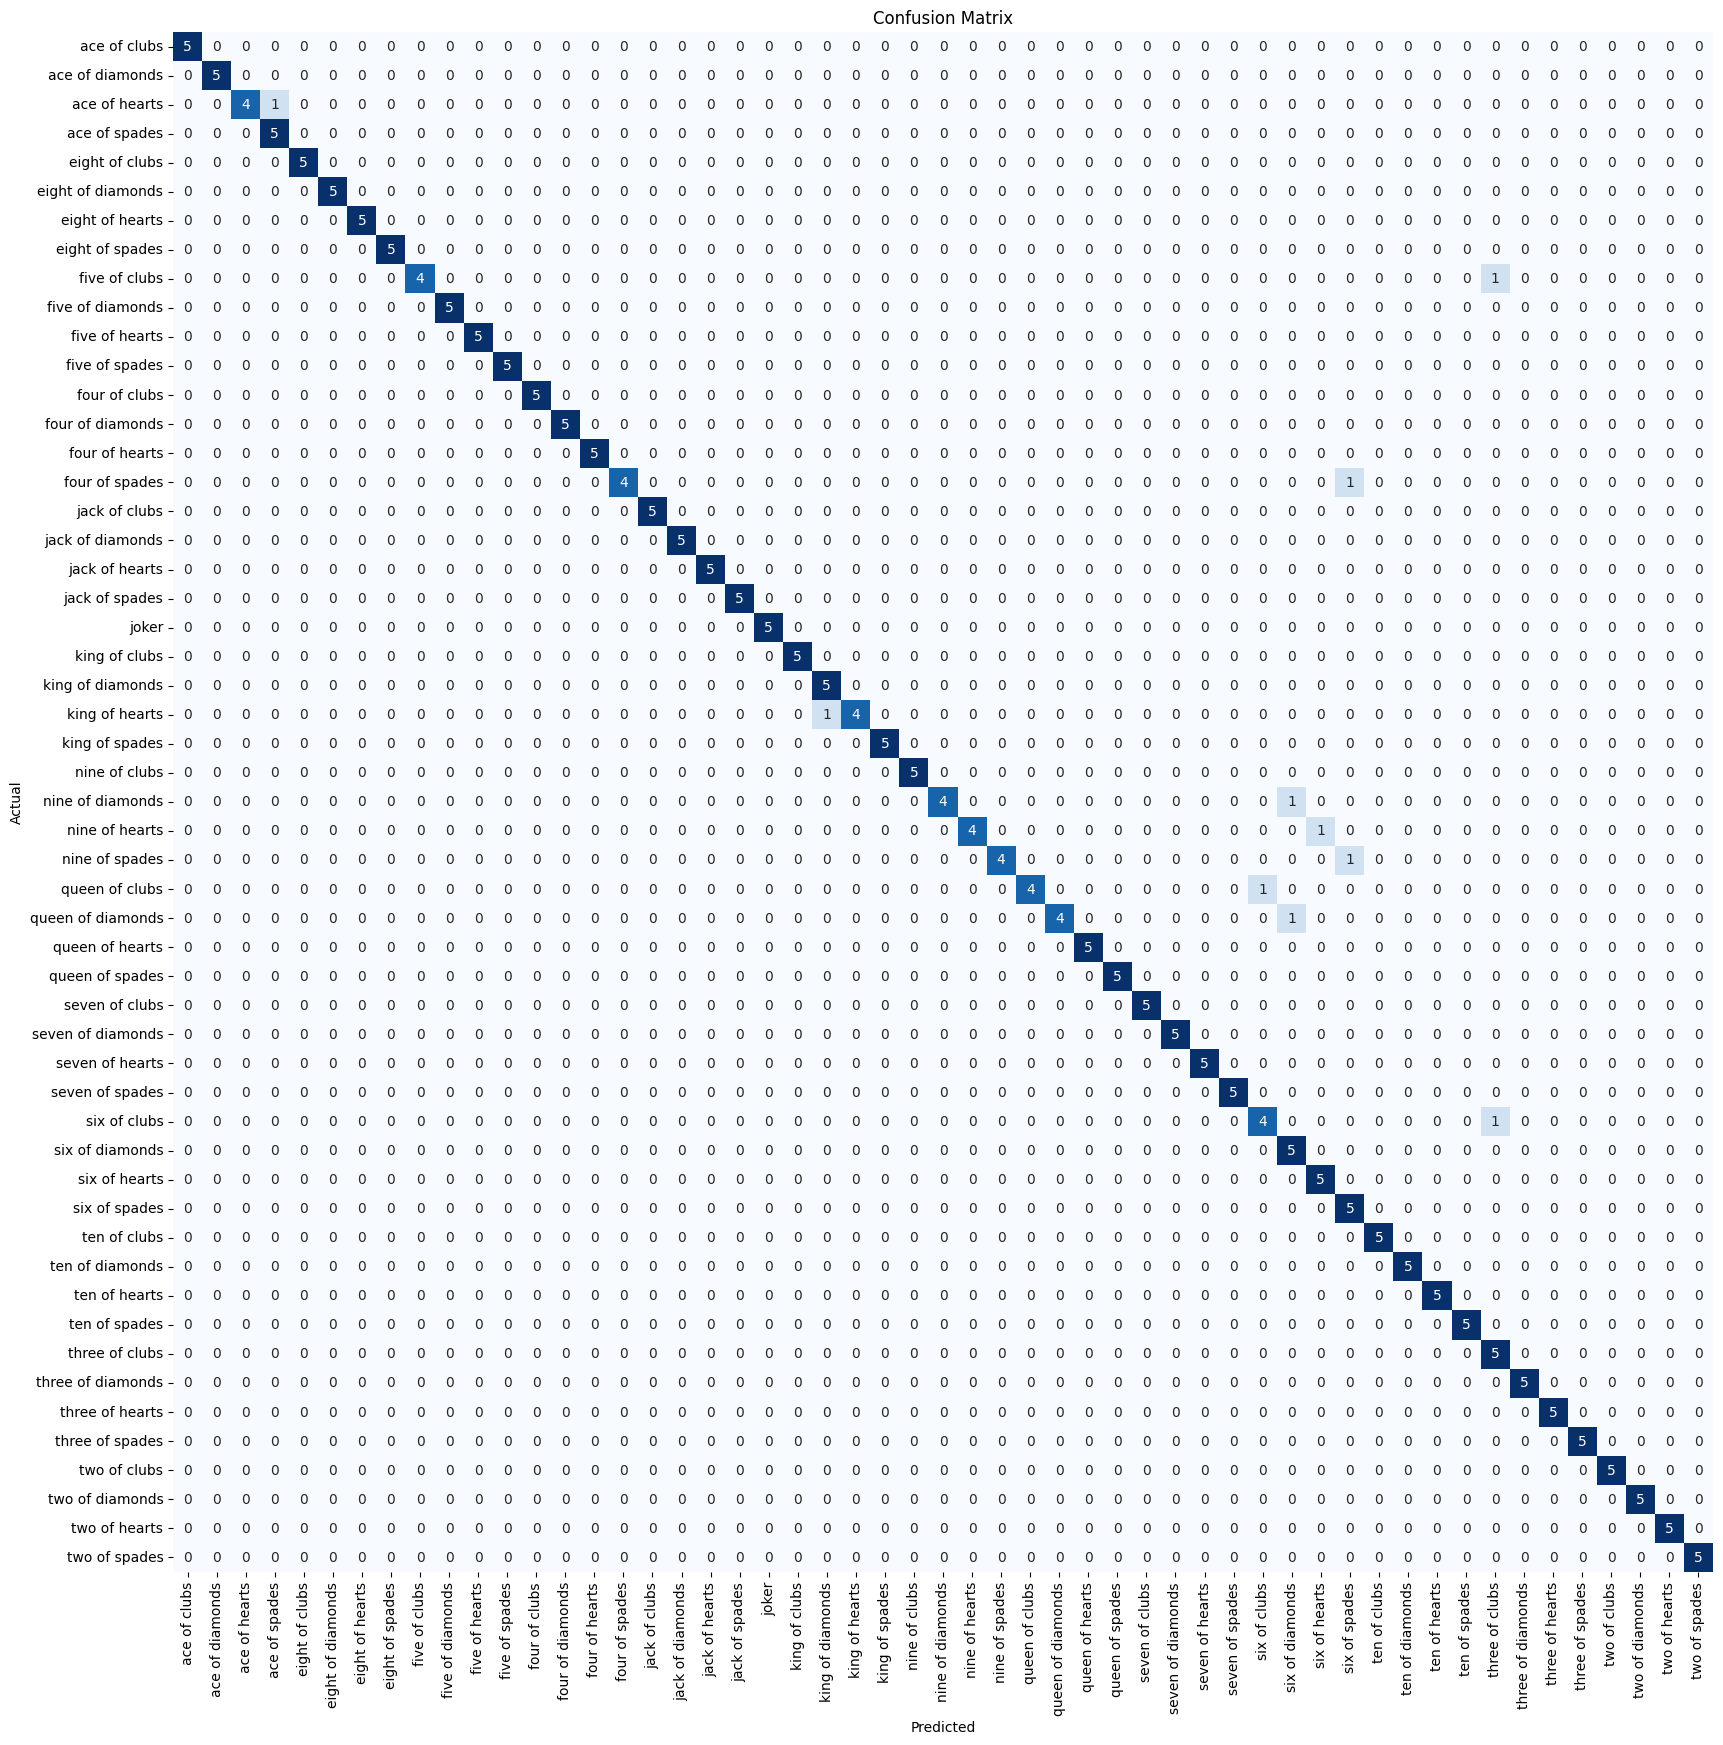

In [ ]:
# Test set

show_report(model, test_loader, DEVICE)
show_matrix(model, test_loader, DEVICE)
